In [1]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def sample_q(n: int,
             mus: torch.Tensor,
             covs: torch.Tensor,
             weights: torch.Tensor) -> torch.Tensor:
    """
    Sample n points from a mixture of 2D Gaussians using PyTorch.
    
    Args:
        n: Number of samples to draw.
        mus: Tensor of shape (K, 2) containing the means of each component.
        covs: Tensor of shape (K, 2, 2) containing the covariance matrices.
        weights: 1D tensor of length K with mixture weights (should sum to 1).
    
    Returns:
        samples: Tensor of shape (n, 2) of drawn samples.
    """
    # Draw component indices according to the mixture weights
    comps = torch.multinomial(weights, n, replacement=True)  # (n,)

    # Gather the means and covariances for the chosen components
    chosen_means = mus[comps]       # (n, 2)
    chosen_covs = covs[comps]       # (n, 2, 2)

    # Create a batched multivariate normal distribution
    mvn = torch.distributions.MultivariateNormal(
        loc=chosen_means,
        covariance_matrix=chosen_covs
    )

    # Sample from the batched distribution
    samples = mvn.sample()          # (n, 2)
    return samples

def velocity_field(x: torch.Tensor,
                   t: float,
                   X_ref: torch.Tensor,
                   sigma_min: float,
                   method: str = 'mc') -> torch.Tensor:
    """
    Compute the velocity field u_t(x) at time t given reference samples X_ref.

    Args:
        x: Tensor of shape (B, d) for current particle positions.
        t: float, current time.
        X_ref: Tensor of shape (N, d) for reference sample points.
        sigma_min: float, minimum noise level.
        method: str, one of 'mc', 'gaussian', 'affine', 'gp'.

    Returns:
        Tensor of shape (B, d) giving velocities for each of the B particles.
    """
    B, d = x.shape
    device, dtype = x.device, x.dtype

    if method == 'mc':
        # Monte Carlo approximation of u_t(x)
        denom = 1.0 - (1.0 - sigma_min) * t
        diffs = x.unsqueeze(1) - t * X_ref.unsqueeze(0)       # (B, N, d)
        sq = torch.sum(diffs ** 2, dim=2)                    # (B, N)
        alphas = torch.exp(-0.5 * sq / (denom ** 2))         # (B, N)
        w = alphas / (alphas.sum(dim=1, keepdim=True) + 1e-12)
        x_bar = w @ X_ref                                    # (B, d)
        return (x_bar - (1 - sigma_min) * x) / denom         # (B, d)

    # Estimate Gaussian parameters from samples
    m = X_ref.mean(dim=0)                                   # (d,)
    diff = X_ref - m                                        # (N, d)
    C = diff.T @ diff / (X_ref.size(0) - 1)                 # (d, d)

    # if method == 'gaussian':
    #     # Closed-form Gaussian flow matching (affine form)
    #     I = torch.eye(d, device=device, dtype=dtype)
    #     mu_t = t * m                                        # (d,)
    #     Sigma_t = (1 - (1 - sigma_min) * t)**2 * I + t**2 * C
    #     dot_mu = m                                          # (d,)
    #     dot_Sigma = (
    #         -2 * (1 - sigma_min) * (1 - (1 - sigma_min) * t) * I
    #         + 2 * t * C
    #     )                                                   # (d, d)
    #     Sigma_inv = torch.linalg.inv(Sigma_t)               # (d, d)
    #     A = 0.5 * dot_Sigma @ Sigma_inv                     # (d, d)
    #     return dot_mu + (x - mu_t) @ A.T                    # (B, d)
    
    if method == 'gaussian':
        # Identity matrix
        I = torch.eye(d, device=device, dtype=dtype)
        # Compute matrix square‐root A = C^{1/2}
        eigvals, eigvecs = torch.linalg.eigh(C)                     # diagonalize C
        A = eigvecs @ torch.diag(torch.sqrt(eigvals)) @ eigvecs.T   # C^{1/2}

        # Mean path and its time‐derivative
        mu_t = t * m                                                # μ_t = t m
        dot_mu = m                                                  # μ̇_t = m

        # Interpolation matrix S_t = (1−t)I + t A
        S_t = (1 - t) * I + t * A

        # Compute linear part of the velocity: A_t = (A−I) S_t^{-1}
        A_mat = (A - I) @ torch.linalg.inv(S_t)

        # Return affine velocity field: v_t(x) = dot_mu + A_t (x - mu_t)
        return dot_mu + (x - mu_t) @ A_mat.T                        # shape (B, d)

    if method == 'affine':
        # Affine MC-CFM velocity: v_t(x) = A_t x + b_t
        I = torch.eye(d, device=device, dtype=dtype)
        # current noise scale
        sigma_t = 1.0 - (1.0 - sigma_min) * t
        # alpha from MC-CFM derivation
        alpha = (1.0 - sigma_min) / sigma_t
        # numerator and denominator for A_t
        num = t * C - (sigma_t**2) * alpha * I                # (d, d)
        den = t**2 * C + (sigma_t**2) * I                     # (d, d)
        A_t = num @ torch.linalg.inv(den)                     # (d, d)
        # bias term
        b_t = m - t * (A_t @ m)                               # (d,)
        # return velocity
        return x @ A_t.T + b_t                               # (B, d)
        

    raise ValueError(f"Unsupported method: {method}")


import torch

def generate_flow_samples(N_gen: int,
                          L_steps: int,
                          dt: float,
                          X_ref: torch.Tensor,
                          sigma_min: float,
                          method: str = 'mc',
                          seed: int = None):
    """
    Generate N_gen samples by pushing standard normal samples through
    flow-matching dynamics via Euler integration—fully vectorized.

    Args:
        N_gen: Number of samples to generate.
        L_steps: Number of time steps.
        dt: Time step size.
        X_ref: Tensor of reference samples, shape (N_mc, 2).
        sigma_min: Minimum noise level.
        method: Velocity computation method, e.g. 'mc'.
        seed: Optional random seed for reproducibility.

    Returns:
        Z0: Initial samples from N(0, I), shape (N_gen, 2).
        X_gen: Final samples after flow, shape (N_gen, 2).
    """
    # Set random seed if provided
    if seed is not None:
        torch.manual_seed(seed)
        # If using CUDA tensors, also seed all GPU devices:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    # Initialize from standard normal (batch of B = N_gen particles)
    Z0 = torch.randn(N_gen, 2)
    X_gen = Z0.clone()

    # Time-stepping loop (vectorized velocity evaluation)
    for l in range(L_steps):
        t = l * dt
        # Compute velocity for all particles at once
        u = velocity_field(X_gen, t, X_ref, sigma_min, method)  # (N_gen, 2)
        # Euler update for the whole batch
        X_gen = X_gen + dt * u

    return Z0, X_gen



def visualize_flow(Z0: torch.Tensor,
                   X_gen: torch.Tensor,
                   X_ref: torch.Tensor,
                   colors):
    """
    Visualize initial and final samples colored by nearest reference sample.
    
    Args:
        Z0: Initial samples, tensor of shape (N_gen, 2).
        X_gen: Final samples after flow, tensor of shape (N_gen, 2).
        X_ref: Reference points, tensor of shape (K, 2).
        colors: Array-like of length K with colors for each reference point.
    """
    # Compute distances and find nearest reference index for each final point
    dists = torch.norm(X_gen.unsqueeze(1) - X_ref.unsqueeze(0), dim=2)  # (N_gen, K)
    nearest_idx = dists.argmin(dim=1).cpu().numpy()                     # (N_gen,)

    # Convert tensors to NumPy for plotting
    Z0_np = Z0.cpu().numpy()
    X_gen_np = X_gen.cpu().numpy()
    X_ref_np = X_ref.cpu().numpy()

    # Plot
    plt.figure(figsize=(10, 5))

    # Initial samples
    plt.subplot(1, 2, 1)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(Z0_np[:, 0], Z0_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.5)
    plt.title("Initial Samples by Nearest Target")
    plt.axis('equal')

    # Final samples
    plt.subplot(1, 2, 2)
    plt.scatter(X_ref_np[:, 0], X_ref_np[:, 1], c=colors, s=80, marker='X')
    plt.scatter(X_gen_np[:, 0], X_gen_np[:, 1], c=[colors[i] for i in nearest_idx],
                s=10, alpha=0.6)
    plt.title("Final Samples by Nearest Target")
    plt.axis('equal')

    plt.tight_layout()
    plt.show()


In [2]:
import torch
import matplotlib.pyplot as plt
import math

# ----------------------------
# Function Definitions (Torch)
# ----------------------------

def compute_likelihood(X: torch.Tensor,
                       y: torch.Tensor,
                       H: torch.Tensor,
                       sigma: float) -> torch.Tensor:
    """
    Compute L(x; y) = N(y | Hx, sigma^2 I) at each row of X.

    Args:
        X: tensor of shape (M, 2) (points at which to evaluate)
        y: tensor of shape (k,) (observed vector)
        H: tensor of shape (k, 2) (linear mapping)
        sigma: observation noise std (scalar)

    Returns:
        Tensor of shape (M,) giving likelihood at each X[i].
    """
    # H x for each point
    Hx = X.matmul(H.t())                                           # (M, k)
    diffs = Hx - y.unsqueeze(0)                                    # (M, k)
    exponent = -0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)      # (M,)
    k = H.shape[0]
    const = (1.0 / ((2 * math.pi * sigma**2) ** (k / 2)))
    return const * torch.exp(exponent)                             # (M,)

def compute_J(X: torch.Tensor,
                y: torch.Tensor,
                H: torch.Tensor,
                sigma: float) -> torch.Tensor:
    """
    Compute L(x; y) = N(y | Hx, sigma^2 I) at each row of X.

    Args:
        X: tensor of shape (M, 2) (points at which to evaluate)
        y: tensor of shape (k,) (observed vector)
        H: tensor of shape (k, 2) (linear mapping)
        sigma: observation noise std (scalar)

    Returns:
        Tensor of shape (M,) giving likelihood at each X[i].
    """
    # H x for each point
    Hx = X.matmul(H.t())                                           # (M, k)
    diffs = Hx - y.unsqueeze(0)                                    # (M, k)
    exponent = 0.5 * torch.sum(diffs**2, dim=1) / (sigma**2)      # (M,)
    return exponent                     # (M,)


def compute_mixture_density(X: torch.Tensor,
                            mus: torch.Tensor,
                            covs: torch.Tensor,
                            weights: torch.Tensor) -> torch.Tensor:
    """
    Compute the density of a 2D Gaussian mixture at each row of X.

    Args:
        X: tensor of shape (M, 2) (evaluation points)
        mus: tensor of shape (K, 2) (component means)
        covs: tensor of shape (K, 2, 2) (covariance matrices)
        weights: tensor of length K (mixture weights)

    Returns:
        Tensor of shape (M,) giving mixture density at each X[i].
    """
    M = X.shape[0]
    total = torch.zeros(M, dtype=X.dtype, device=X.device)
    two_pi = 2 * math.pi

    for mu, cov, w in zip(mus, covs, weights):
        inv_cov = torch.inverse(cov)                               # (2,2)
        det_cov = torch.det(cov)                                   # scalar
        norm_const = 1.0 / (two_pi * torch.sqrt(det_cov))
        diff = X - mu.unsqueeze(0)                                 # (M,2)
        exp_term = torch.exp(-0.5 * torch.sum(diff @ inv_cov * diff, dim=1))
        total += w * norm_const * exp_term

    return total                                                   # (M,)


def visualize_heatmap(grid_size: tuple,
                      lims: list,
                      mus: torch.Tensor,
                      covs: torch.Tensor,
                      weights: torch.Tensor,
                      H: torch.Tensor,
                      y_obs: torch.Tensor,
                      sigma_obs: float):
    """
    Plot original density, likelihood, and posterior heatmaps.

    Args:
        grid_size: (nx, ny) number of pixels in x and y
        lims: [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)            # (nx*ny,2)

    # compute values
    rho = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L   = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid and convert to numpy
    rho_np  = rho.view(ny, nx).cpu().numpy()
    L_np    = L.view(ny, nx).cpu().numpy()
    post_np = post.view(ny, nx).cpu().numpy()

    # plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, data, title in zip(axes,
                               (rho_np, L_np, post_np),
                               ("Original density ρ(x)",
                                "Likelihood L(x; y)",
                                "Unnormalized posterior ρ·L")):
        im = ax.imshow(data,
                       extent=(x_min, x_max, y_min, y_max),
                       origin='lower', aspect='auto')
        ax.set_title(title)
        ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


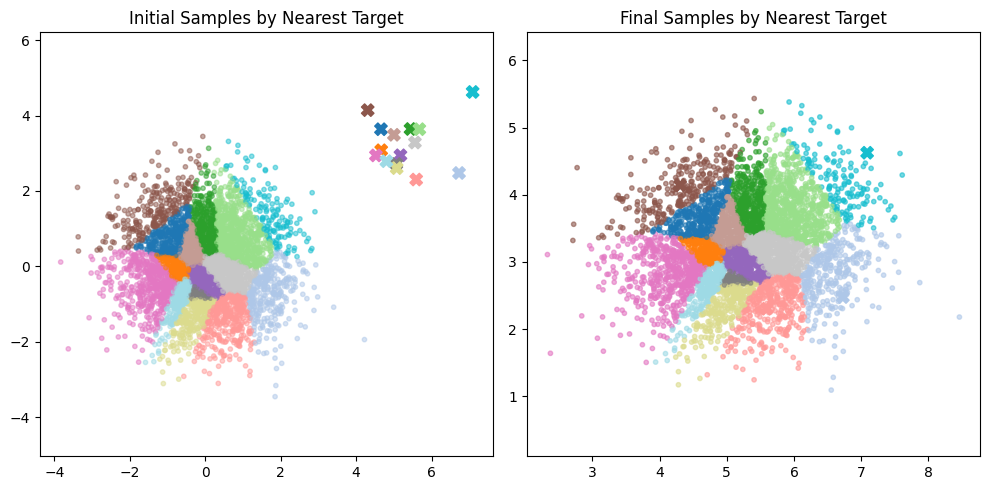

Gaussian flow–matched samples mean:
tensor([5.2866, 3.2331])
Gaussian flow–matched samples covariance:
tensor([[0.6131, 0.0713],
        [0.0713, 0.4145]])


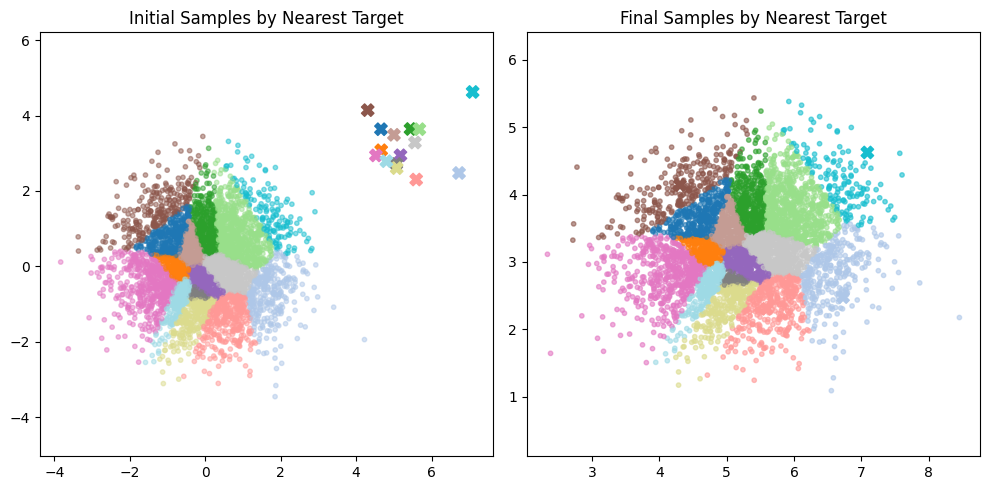

Affine flow–matched samples mean:
tensor([5.2866, 3.2331])
Affine flow–matched samples covariance:
tensor([[0.6099, 0.0698],
        [0.0698, 0.4154]])
Average L2 distance between Gaussian and affine samples:
tensor(0.0022)
torch.Size([5000])


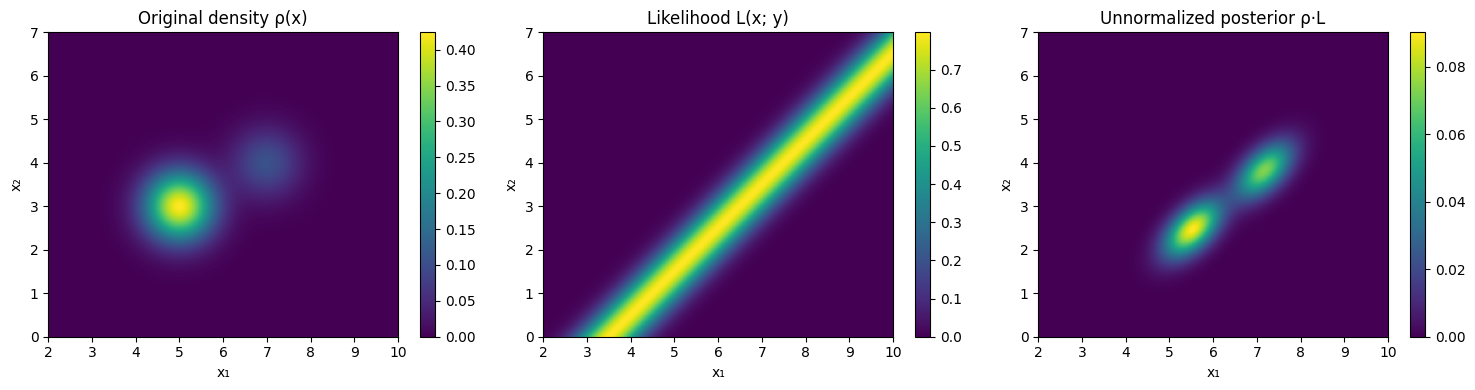

In [69]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Main: Parameter Settings and Execution (Torch)
# ----------------------------

# Monte Carlo and generation settings
N_mc      = 15
N_gen     = 5000
sigma_min = 1e-1
L_steps   = 100
dt        = 1.0 / L_steps

# target Gaussian mixture parameters (convert to torch tensors)
mus     = torch.tensor([[5.0, 3.0],
                        [7.0, 4.0]], dtype=torch.float32)            # (K=2, 2)
covs    = torch.stack([0.3 * torch.eye(2),
                       0.3 * torch.eye(2)], dim=0)                  # (K=2, 2, 2)
weights = torch.tensor([0.8,0.2], dtype=torch.float32)               # (K,)

# sample reference targets
X_mc = sample_q(N_mc, mus, covs, weights)                              # (N_mc, 2)

# assign colors for each reference sample (for plotting)
colors = plt.cm.tab20(np.linspace(0, 1, N_mc))

# generate flow‐matched samples (Gaussian displacement interpolation)
Z0, X_gen_1 = generate_flow_samples(
    N_gen, L_steps, dt, X_mc, sigma_min,
    method='gaussian', seed=42
)  # both (N_gen, 2)

# visualize the transformation with torch‐based functions
visualize_flow(Z0, X_gen_1, X_mc, colors)

# Gaussian flow–matched samples: print mean, then covariance
print("Gaussian flow–matched samples mean:")
print(X_gen_1.mean(dim=0))
print("Gaussian flow–matched samples covariance:")
print(X_gen_1.T.cov())

# generate flow‐matched samples (optimal‐transport affine)
Z0, X_gen_2 = generate_flow_samples(
    N_gen, L_steps, dt, X_mc, sigma_min,
    method='affine', seed=42
)  # both (N_gen, 2)

# visualize the transformation with torch‐based functions
visualize_flow(Z0, X_gen_2, X_mc, colors)

# Affine flow–matched samples: print mean, then covariance
print("Affine flow–matched samples mean:")
print(X_gen_2.mean(dim=0))
print("Affine flow–matched samples covariance:")
print(X_gen_2.T.cov())

# compare the two sets
print("Average L2 distance between Gaussian and affine samples:")
print(torch.norm(X_gen_1 - X_gen_2, dim=1).mean())
print(torch.norm(X_gen_1 - X_gen_2, dim=1).shape)


# ----------------------------
# Heatmap Visualization
# ----------------------------
grid_size = (250, 250)            # grid resolution per axis
lims      = [(2, 10), (0, 7)]      # x and y limits

# observation model parameters (as torch tensors)
H         = torch.tensor([[1.0, -1.0]], dtype=torch.float32)          # (1, 2)
y_obs     = torch.tensor([3.5], dtype=torch.float32)                  # (1,)
sigma_obs = 0.5                                                        # scalar

# plot original density, likelihood, and posterior heatmaps
visualize_heatmap(grid_size, lims,
                  mus, covs, weights,
                  H, y_obs, sigma_obs)


In [70]:
import torch
import torch.nn.functional as F

import torch
import torch.nn.functional as F

def guidance(
    xt: torch.Tensor,
    x1_samples: torch.Tensor,
    t,
    sigma_min: float,
    J_fn,
    dot_xt_unguided: torch.Tensor = None,
    method: str = "mc",
    M: int = 10,
    v_fn=None,
) -> torch.Tensor:
    """
    Compute the guidance vector field g_t(x) via three methods:
      - "mc"        : Monte Carlo estimator
      - "local"     : local gradient-based
      - "time-affine": fit g(x) = A_t x + b_t by weighted least squares

    Args:
        xt:               [B, D] current states (used for output shape)
        x1_samples:       [N, D] posterior samples from p(x1)
        t:                float or [B] tensor in [0,1]
        sigma_min:        float endpoint variance parameter
        J_fn:             Callable mapping [N, D] → [N], energy J(x1)
        dot_xt_unguided:  [B, D] unguided velocity v_t(x) (local mode)
        method:           "mc", "local", or "time-affine"
        M:                int, number of conditional samples per x1 (time-affine)
        v_fn:             Callable mapping [*, D] → [*, D], must be provided in time-affine

    Returns:
        g: [B, D] guidance vector field
    """
    B, D = xt.shape
    device, dtype = xt.device, xt.dtype

    # make t a tensor [B]
    if not torch.is_tensor(t):
        t = torch.full((B,), t, device=device, dtype=dtype)
    else:
        t = t.to(device=device, dtype=dtype)

    if method == "mc":
        # --- Monte Carlo guidance (unchanged) ---
        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"
        sigma_t = 1 - (1 - sigma_min) * t              # [B]
        denom   = sigma_t

        # expand for pairwise
        xt_exp = xt.unsqueeze(0).expand(N, B, D)
        x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)
        t_exp  = t.view(1, B, 1)

        dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)      # [N,B]
        inv_two_sig2 = 1.0 / (2 * sigma_t.pow(2))
        inv_two_sig2 = inv_two_sig2.view(1, B)
        log_alpha    = -dist2 * inv_two_sig2                       # [N,B]
        weights      = F.softmax(log_alpha, dim=0)                 # [N,B]

        J_vals   = J_fn(x1_samples)                                # [N]
        exp_negJ = torch.exp(-J_vals).view(N,1)                    # [N,1]
        Z_tilde  = (weights * exp_negJ).sum(dim=0)                  # [B]

        v_cond = (x1_exp - (1 - sigma_min) * xt_exp) / denom.view(1,B,1)  # [N,B,D]

        coeff          = exp_negJ / Z_tilde.view(1,B) - 1.0         # [N,B]
        weighted_coeff = coeff * weights                           # [N,B]

        g = (weighted_coeff.unsqueeze(-1) * v_cond).sum(dim=0)      # [B,D]
        return g
    
    elif method == "mc-gm":
        # --- Monte Carlo Guidance Matching (MC-GM) ---  
        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"
        sigma_t = 1 - (1 - sigma_min) * t  # [B]

        # pairwise expansions
        xt_exp = xt.unsqueeze(0).expand(N, B, D)
        x1_exp = x1_samples.unsqueeze(1).expand(N, B, D)
        t_exp  = t.view(1, B, 1)

        # conditional density weights
        dist2        = (xt_exp - t_exp * x1_exp).pow(2).sum(-1)  # [N, B]
        inv_two_sig2 = (1.0 / (2 * sigma_t.pow(2))).view(1, B)
        log_alpha    = -dist2 * inv_two_sig2                   # [N, B]
        alpha        = torch.softmax(log_alpha, dim=0)         # [N, B]

        # compute normalization Z_t(x)
        J_vals   = J_fn(x1_samples)                            # [N]
        exp_negJ = torch.exp(-J_vals).view(N, 1)               # [N, 1]
        Z_t      = (alpha * exp_negJ).sum(dim=0)               # [B]

        # true conditional drift u_t(x|x1)
        u_cond   = (x1_exp - (1 - sigma_min) * xt_exp) / sigma_t.view(1, B, 1)  # [N, B, D]

        # guidance coefficients: (e^{-J}/Z_t - 1)
        coeff    = exp_negJ / Z_t.view(1, B) - 1.0              # [N, B]
        w        = alpha * coeff                                # [N, B]

        # aggregate vector field
        g = (w.unsqueeze(-1) * u_cond).sum(dim=0)               # [B, D]
        return g

    elif method == "local":
        # --- Local gradient-based guidance ---
        if dot_xt_unguided is None:
            raise ValueError("dot_xt_unguided must be provided for local guidance")
        # first-order x1 prediction
        x1_pred = xt + (1 - t).unsqueeze(-1) * dot_xt_unguided     # [B,D]
        x1_pred.requires_grad_()
        energy = J_fn(x1_pred).sum()
        grad, = torch.autograd.grad(energy, x1_pred)
        return -grad                                               # [B,D]

    elif method == "time-affine":
        # --- Time-affine guidance: fit A_t, b_t to match u_t - v_t ---
        if v_fn is None:
            raise ValueError("v_fn must be provided for time-affine guidance")

        # enforce single shared t across batch
        t0 = float(t.view(-1)[0].item())
        sigma_t = 1 - (1 - sigma_min) * t0

        N, D1 = x1_samples.shape
        assert D1 == D, "Dimension mismatch"

        # compute weights w_n ∝ exp(-J(x1_n))
        J_vals = J_fn(x1_samples)                                # [N]
        w     = torch.exp(-J_vals)
        w    /= w.sum()                                           # [N]

        # draw M conditional samples per x1_n: x_t^{m,n} ~ N(t x1_n, σ_t^2 I)
        # shape [N, M, D]
        x1_expanded = x1_samples.unsqueeze(1).expand(N, M, D)
        noise       = torch.randn(N, M, D, device=device, dtype=dtype) * sigma_t
        xt_samples  = t0 * x1_expanded + noise                    

        # true conditional drift u_t(x|x1)
        u_true = (x1_expanded - (1 - sigma_min) * xt_samples) / sigma_t  # [N,M,D]

        # evaluate prior velocity at each sample
        X_flat     = xt_samples.reshape(-1, D)                    # [N*M, D]
        U_flat     = u_true.reshape(-1, D)
        v_prior    = v_fn(X_flat)                                 # [N*M, D]

        # targets = u_true - v_t(x)
        Y_flat     = (U_flat - v_prior)                            # [N*M, D]

        # build weighted least-squares problem
        # weights per sample = w_n / M
        w_per_x1   = (w / M).view(N, 1).expand(N, M)               # [N,M]
        W_flat     = w_per_x1.reshape(-1)                          # [N*M]

        # design matrix [X | 1]
        ones       = torch.ones(X_flat.size(0), 1, device=device, dtype=dtype)
        X_aug      = torch.cat([X_flat, ones], dim=1)              # [N*M, D+1]

        # solve Θ = argmin ‖W^(1/2)(X_aug Θ - Y)‖²  via normal equations
        # Θ = (X_aug^T W X_aug)^{-1} X_aug^T W Y
        W_diag     = torch.diag(W_flat)
        XtW        = X_aug.t() @ W_diag
        Theta      = torch.linalg.solve(XtW @ X_aug, XtW @ Y_flat)  # [D+1, D]

        # extract A_t and b_t
        A_t = Theta[:-1, :]                                        # [D, D]
        b_t = Theta[-1, :]                                         # [D]

        # apply to each xt in the batch
        g = xt @ A_t + b_t                                          # [B, D]
        return g
    
    elif method == "affine-gm":
        # --- Affine-GM: guidance matching MC ---
        # enforce single t
        t0 = float(t.view(-1)[0].item())
        sigma_t0 = 1 - (1 - sigma_min) * t0
        N, D1 = x1_samples.shape
        assert D1 == D

        # compute energy values
        J_vals = J_fn(x1_samples)              # [N]
        exp_negJ = torch.exp(-J_vals)          # [N]

        # draw M conditional samples per x1
        x1_exp = x1_samples.unsqueeze(1).expand(N, M, D)
        noise = torch.randn(N, M, D, device=device, dtype=dtype) * sigma_t0
        xt_samps = t0 * x1_exp + noise         # [N, M, D]

        # true u_t
        u_true = (x1_exp - (1 - sigma_min) * xt_samps) / sigma_t0  # [N, M, D]

        # compute Z_hat for each sample
        # flatten for ease
        xt_flat = xt_samps.reshape(-1, D)      # [N*M, D]
        # pairwise dist2 to all x1_samples
        x1_all = x1_samples.unsqueeze(0).expand(N*M, N, D)       # [N*M, N, D]
        xt_all = xt_flat.unsqueeze(1).expand(N*M, N, D)
        dist2 = (xt_all - t0 * x1_all).pow(2).sum(-1)             # [N*M, N]
        inv_two_sig2 = 1.0 / (2 * sigma_t0**2)
        log_p = -dist2 * inv_two_sig2                           # [N*M, N]
        # subtract max for stability
        log_p_max = log_p.max(dim=1, keepdim=True)[0]
        p_stable = torch.exp(log_p - log_p_max)

        # numerator and denominator of Z_hat
        exp_negJ_expand = exp_negJ.view(1, N).expand(N*M, N)
        num = (p_stable * exp_negJ_expand).sum(dim=1)           # [N*M]
        den = p_stable.sum(dim=1)                               # [N*M]
        Z_hat = num / den                                       # [N*M]

        # compute coeff c = exp(-J(x1_n)) / Z_hat - 1
        # create index for each flattened sample to its x1 index
        idx = torch.arange(N, device=device).unsqueeze(1).expand(N, M).reshape(-1)
        exp_negJ_idx = exp_negJ[idx]                            # [N*M]
        coeff = exp_negJ_idx / Z_hat - 1.0                      # [N*M]

        # targets Y = c * u_true
        Y_flat = (coeff.unsqueeze(-1) * u_true.reshape(-1, D))  # [N*M, D]

        # build design matrix
        ones = torch.ones(N*M, 1, device=device, dtype=dtype)
        X_aug = torch.cat([xt_flat, ones], dim=1)               # [N*M, D+1]

        # solve least squares: Theta = (X_aug^T X_aug)^-1 X_aug^T Y
        XtX = X_aug.t() @ X_aug
        XtY = X_aug.t() @ Y_flat
        Theta = torch.linalg.solve(XtX, XtY)                   # [D+1, D]

        A_t = Theta[:-1, :]
        b_t = Theta[-1, :]
        return xt @ A_t + b_t
    
    else:
        raise ValueError(f"Unknown method: {method}")


def shifted_nearest_rows(X0: torch.Tensor,
                         Xt: torch.Tensor,
                         X1: torch.Tensor,
                         t: float) -> torch.Tensor:

    # 1. Scale the candidate matrix once
    tX1 = t * X1                          # (M, d)

    # 2. Compute every shifted candidate: D[n, m, :] = tX1[m] - X0[n]
    D = tX1.unsqueeze(0) - X0.unsqueeze(1)   # Shape: (N, M, d)

    # 3. Difference to each Xt[n]
    diff = D - Xt.unsqueeze(1)            # Shape: (N, M, d)

    # 4. Squared Euclidean distances for all (n, m) pairs
    dist2 = (diff ** 2).sum(dim=2)        # Shape: (N, M)

    # 5. Index m* of the nearest candidate for every n
    m_star = dist2.argmin(dim=1)          # Shape: (N,)

    # 6. Gather the corresponding rows from D to form V
    idx = m_star.unsqueeze(1).unsqueeze(2).expand(-1, 1, X0.size(1))  # (N, 1, d)
    V = D.gather(dim=1, index=idx).squeeze(1)   # (N, d)

    return V

tensor(0.6880)
tensor(0.9231)
tensor(0.5579)
tensor(0.8458)
tensor(0.5048)
tensor(0.7859)
tensor(0.9000)
tensor(0.7927)
tensor(0.8945)
tensor(0.8241)
tensor(0.8641)
tensor(0.4332)
tensor(0.5098)
tensor(0.8573)
tensor(0.6722)
tensor(0.9169)
tensor(0.8689)
tensor(0.9082)
tensor(0.7325)
tensor(0.5668)
tensor(0.6207)
tensor(0.7812)
tensor(0.8742)
tensor(0.9083)
tensor(0.7085)
tensor(0.9026)
tensor(0.5126)
tensor(0.8843)
tensor(0.8069)
tensor(0.3713)
tensor(0.7833)
tensor(0.6552)
tensor(0.2799)
tensor(0.3905)
tensor(0.6396)
tensor(0.4409)
tensor(0.4098)
tensor(0.5767)
tensor(0.8237)
tensor(0.1456)
tensor(0.8671)
tensor(0.7781)
tensor(0.7672)
tensor(0.9021)
tensor(0.4234)
tensor(0.8176)
tensor(0.0110)
tensor(0.2113)
tensor(0.8438)
tensor(0.7135)
tensor(0.8906)
tensor(0.7909)
tensor(0.7637)
tensor(0.4094)
tensor(0.0099)
tensor(0.1125)
tensor(0.2298)
tensor(0.3102)
tensor(0.8286)
tensor(0.8161)
tensor(0.7806)
tensor(0.2685)
tensor(0.5452)
tensor(0.3916)
tensor(0.4893)
tensor(0.2897)
tensor(-0.

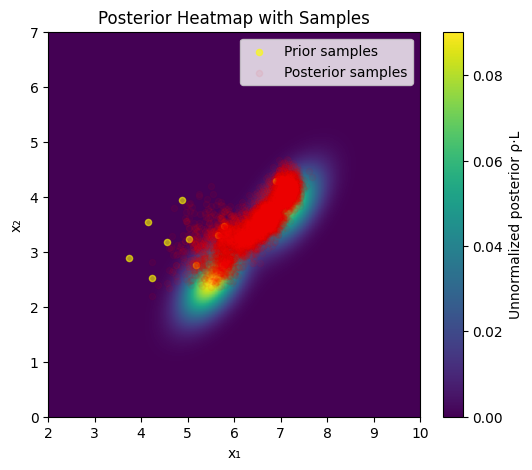

In [72]:
def visualize_posterior(grid_size: tuple,
                        lims: list,
                        mus: torch.Tensor,
                        covs: torch.Tensor,
                        weights: torch.Tensor,
                        H: torch.Tensor,
                        y_obs: torch.Tensor,
                        sigma_obs: float,
                        X_post: torch.Tensor,
                        x1_samples: torch.Tensor):
    """
    Plot the unnormalized posterior heatmap ρ(x)·L(x; y) and overlay posterior samples.

    Args:
        grid_size:     (nx, ny) grid resolution
        lims:          [(x_min, x_max), (y_min, y_max)]
        mus, covs, weights: mixture parameters (torch tensors)
        H, y_obs, sigma_obs: likelihood parameters
        X_post:        Tensor [N_post, 2] of posterior samples to scatter
    """
    (x_min, x_max), (y_min, y_max) = lims
    nx, ny = grid_size

    # create grid of points
    xs = torch.linspace(x_min, x_max, nx)
    ys = torch.linspace(y_min, y_max, ny)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')                # (nx,ny)
    pts = torch.stack([Xg.ravel(), Yg.ravel()], dim=1)             # (nx*ny,2)

    # compute unnormalized posterior = ρ(x) * L(x; y)
    rho  = compute_mixture_density(pts, mus, covs, weights)        # (nx*ny,)
    L    = compute_likelihood(pts, y_obs, H, sigma_obs)            # (nx*ny,)
    post = rho * L                                                # (nx*ny,)

    # reshape to grid
    post_grid = post.view(ny, nx).cpu().numpy()

    # plot posterior heatmap
    plt.figure(figsize=(6, 5))
    plt.imshow(post_grid,
               extent=(x_min, x_max, y_min, y_max),
               origin='lower',
               aspect='auto')
    plt.colorbar(label="Unnormalized posterior ρ·L")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title("Posterior Heatmap with Samples")

    # overlay posterior samples
    Xn = x1_samples[:, 0].cpu().numpy()
    Yn = x1_samples[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='yellow', s=20, alpha=0.6, label="Prior samples")
    Xn = X_post[:, 0].cpu().numpy()
    Yn = X_post[:, 1].cpu().numpy()
    plt.scatter(Xn, Yn, c='red', s=20, alpha=0.05, label="Posterior samples")
    plt.legend()
    plt.show()
    
def average_cosine_similarity(A: torch.Tensor, 
                              B: torch.Tensor, 
                              eps: float = 1e-8) -> torch.Tensor:
    """
    Compute the average row-wise cosine similarity between two tensors A and B.

    Args:
        A (torch.Tensor): Tensor of shape (N, 2).
        B (torch.Tensor): Tensor of shape (N, 2).
        eps (float): Small value to avoid division by zero.

    Returns:
        torch.Tensor: Scalar tensor containing the mean cosine similarity.
    """
    # 1. compute row-wise dot products, shape (N,)
    dot = torch.sum(A * B, dim=1)

    # 2. compute row-wise L2 norms, each shape (N,)
    normA = torch.norm(A, p=2, dim=1)
    normB = torch.norm(B, p=2, dim=1)

    # 3. cosine similarity per row
    cos_sim = dot / (normA * normB + eps)

    # 4. return the mean cosine similarity
    return cos_sim.mean()

# ———————————————
# Posterior sampling with MC guidance (flow + guidance)
# ———————————————

torch.manual_seed(42)
# 1. Draw MC target samples once (for guidance)
x1_samples = sample_q(N_mc, mus, covs, weights)    # [N_mc, 2]

# 2. Initialize reference points from the prior
# X_post = sample_q(N_gen, mus, covs, weights)       # [N_gen, 2]
X_post = torch.randn(N_gen, 2)

# 3. Define energy J(x) = - log likelihood
def J_fn(x): 
    return compute_J(x, y_obs, H, sigma_obs)                                

def _v_fn(X, t):
    return velocity_field(X, t, x1_samples, sigma_min=1e-3, method='mc')

X0 = X_post
# 4. Euler integration: base flow v_t + MC guidance g_t
for i in range(L_steps):
    t_i    = i * dt
    v_base = velocity_field(X_post, t_i, x1_samples, sigma_min=0.2, method='mc')
    if t_i > 0:
        dot_xt_unguided = shifted_nearest_rows(X0, X_post, x1_samples, t_i) 
    else:
        dot_xt_unguided = v_base
    g = guidance(X_post, x1_samples, t_i, sigma_min=1e-3, J_fn=J_fn, dot_xt_unguided=dot_xt_unguided, method='affine-gm', M=20, v_fn=lambda x: _v_fn(x, t_i))             # [N_gen, 2]
    cos_sim = average_cosine_similarity(v_base, g)
    print(cos_sim)
    X_post = X_post + dt * (v_base + g)

visualize_posterior(grid_size, lims,
                    mus, covs, weights,
                    H, y_obs, sigma_obs,
                    X_post, x1_samples)


In [33]:
import torch

# compute distance matrix
dist_mat = torch.cdist(X_post, x1_samples)
print(dist_mat.shape)  # e.g. (N, M)

# get the minimum distance for each row: returns (values, indices)
min_vals, _ = torch.min(dist_mat, dim=1)

# now take the maximum over those minima
maxmin_d = torch.max(min_vals)

print("The maximum of the minimal distance between each posterior samples to all prior samples", maxmin_d)


torch.Size([50000, 15])
The maximum of the minimal distance between each posterior samples to all prior samples tensor(0.6790)
